# Building an Uncertainty Budget - `curve_fit` version using only y-uncertainties

V1: Mar 10, 2026

## 1. Motivation

When you are looking to iterate and improve on an experiment, you need to ask yourself how much does the uncertainty in each of your measurements contribute to the uncertainty in your final result? If you could improve one thing about your measurement approach, which would help most? An Uncertainty Budget can help answer that. We use a radiation attenuation experiment for this example, but the approach works for any experiment where you extract a parameter from a fit.

## 2. The approach for estimating contributions to your overall uncertainty budget

For each uncertainty source we ask "what would happen if this measurement were twice as imprecise?" To do this, we double that source's uncertainty, repeat the fit, and then record how much the output uncertainty grows. This allows us to determine how much that uncertainty source contributed to the uncertainty in the final result.

Let's look at this in more detail. Since independent uncertainty sources add in quadrature, we can write:

$$\delta\mu_{\text{full}}^2 = \text{impact}_1^2 + \text{impact}_2^2 + \cdots.$$

And then when fitting, each source's contribution to $\delta\mu$ scales linearly with its input uncertainty (see note below): double $\sigma_i$, and $\text{impact}_i$ doubles. Doubling source $\sigma_i$ therefore replaces $\text{impact}_i^2$ with $(2\,\text{impact}_i)^2 = 4\,\text{impact}_i^2$ in the sum, leaving all other terms unchanged:

$$\delta\mu_{\text{doubled}}^2 = \delta\mu_{\text{full}}^2 + 3\,\text{impact}_i^2.$$

Here $3 = 4 - 1$: the doubled term grew by a factor of 4, so the net increase of $\delta\mu$ over the baseline is 3 times the original contribution. Solving for the impact gives

$$\text{impact}_i = \sqrt{\frac{\delta\mu_{\text{doubled}}^2 - \delta\mu_{\text{full}}^2}{3}}.$$

Our approach for different sources of uncertainty:

* **A per-point source**, which is independent at each data point (such as counting statistics or timing scatter): double its contribution to the error bars and refit.

* **A shared source**, which is a single measured value contributing the same uncertainty to all data points (such as a background measurement subtracted from all data): double its contribution to the error bars and refit.

In `curve_fit`, both types enter through the per-point `sigma` array, so the procedure is the same.

**Note:** The linear scaling requires `absolute_sigma=True` in `curve_fit`, which ensures that parameter uncertainties scale with the input `sigma` values rather than with how well the model fits the data.

## 3. Worked example: radiation attenuation through paper

### 3.1 The radiation attenuation experiment

Beta radiation from a radioactive source passes through sheets of paper to reach a Geiger counter. Each sheet absorbs some fraction of the radiation, so the count rate falls exponentially with the number of sheets $n$:

$$R(n) = R_0 \, e^{-n/\mu}$$

where $R_0$ is the source count rate with no shielding and $\mu$ is the attenuation length in sheets (the number of sheets needed to reduce the intensity by a factor of $e$). We measure background radiation separately and subtract it before fitting, so the model does not need a background parameter.

### 3.2 Uncertainty sources

Three sources contribute to the uncertainty on each background-subtracted count rate $R_{\text{sub},i}$:

| Source | Value | Affects | Character |
|:------:|:-----:|:-------:|:---------:|
| Counting statistics ($\delta N = \sqrt{N}$) | Varies | Per-point $R_i$ | Per-point (Poisson) |
| Timing ($\delta t$) | ~0.2 s | Per-point $R_i$ | Per-point (resolution + reaction) |
| Background ($\delta R_{\text{bg}}$) | ~0.017 counts/s | All $R_{\text{sub},i}$ equally | Shared (single measurement) |

### 3.3 Sample data

We count radiation through $n = 0, 1, 2, \ldots, 6, 8, 10, 12, 15$ sheets of paper. For 0–6 sheets we count for about 2 minutes; for 8–15 sheets we count longer (~5 minutes) to accumulate better statistics at low rates. A separate background measurement without the source runs for ~10 minutes. All times are recorded to 0.1 s resolution.

The timing uncertainty per measurement combines the 0.1 s timer resolution (rectangular distribution, $\sigma = 0.1/(2\sqrt{3})$) with a ~0.2 s human reaction time on the stop click:

$$\delta t = \sqrt{\left(\frac{0.1}{2\sqrt{3}}\right)^2 + 0.2^2} \approx 0.202 \text{ s}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
# Sheets of paper (the x-variable; exact integer count)
n_sheets = np.array([0, 1, 2, 3, 4, 5, 6, 8, 10, 12, 15])

# Raw counts and counting times (s)
N_counts = np.array([2477, 1661, 1131, 736, 473, 332, 245, 290, 144, 111, 56])
t_count  = np.array([119.6, 121.4, 120.7, 120.3, 119.1, 119.1, 118.7,
                     301.1, 300.3, 300.6, 298.6])

# Background measurement (no source, ~10 minutes)
N_bg = 98
t_bg = 599.8

# Timing uncertainty per measurement
dt = np.sqrt((0.1 / (2 * np.sqrt(3)))**2 + 0.2**2)

### 3.4 Derived quantities

The background rate is $R_{\text{bg}} = N_{\text{bg}} / t_{\text{bg}}$, and the background-subtracted rate at each point is

$$R_{\text{sub},i} = \frac{N_i}{t_i} - R_{\text{bg}}.$$

The combined uncertainty on each subtracted rate has three independent components:

$$\delta R_i = \sqrt{\left(\frac{\sqrt{N_i}}{t_i}\right)^2 + \left(\frac{N_i}{t_i}\cdot\frac{\delta t}{t_i}\right)^2 + \left(\frac{\sqrt{N_{\text{bg}}}}{t_{\text{bg}}}\right)^2}$$

The first term is counting statistics (Poisson), the second is timing uncertainty on the signal measurement, and the third is the background measurement uncertainty (same value for all points).

In [3]:
R_bg = N_bg / t_bg
dR_bg = np.sqrt(N_bg) / t_bg
R_raw = N_counts / t_count
R_sub = R_raw - R_bg

# Separate uncertainty components
dR_count = np.sqrt(N_counts) / t_count
dR_time = R_raw * dt / t_count
dR_total = np.sqrt(dR_count**2 + dR_time**2 + dR_bg**2)

print(f'Background: R_bg = {R_bg:.4f} ± {dR_bg:.4f} counts/s')
print(f'            ({N_bg} counts in {t_bg} s)')
print()
print(f'{"n_sheets":>8s}  {"N":>5s}  {"t (s)":>7s}  {"R_sub":>7s}  {"δR_count":>8s}'
      f'  {"δR_time":>8s}  {"δR_bg":>8s}  {"δR_total":>8s}')
print('-' * 73)
for i in range(len(n_sheets)):
    print(f'{n_sheets[i]:8d}  {N_counts[i]:5d}  {t_count[i]:7.1f}  {R_sub[i]:7.3f}'
          f'  {dR_count[i]:8.4f}  {dR_time[i]:8.5f}  {dR_bg:8.4f}  {dR_total[i]:8.4f}')

Background: R_bg = 0.1634 ± 0.0165 counts/s
            (98 counts in 599.8 s)

n_sheets      N    t (s)    R_sub  δR_count   δR_time     δR_bg  δR_total
-------------------------------------------------------------------------
       0   2477    119.6   20.547    0.4161   0.03499    0.0165    0.4179
       1   1661    121.4   13.519    0.3357   0.02277    0.0165    0.3369
       2   1131    120.7    9.207    0.2786   0.01569    0.0165    0.2796
       3    736    120.3    5.955    0.2255   0.01028    0.0165    0.2264
       4    473    119.1    3.808    0.1826   0.00674    0.0165    0.1835
       5    332    119.1    2.624    0.1530   0.00473    0.0165    0.1539
       6    245    118.7    1.901    0.1319   0.00351    0.0165    0.1329
       8    290    301.1    0.800    0.0566   0.00065    0.0165    0.0589
      10    144    300.3    0.316    0.0400   0.00032    0.0165    0.0432
      12    111    300.6    0.206    0.0350   0.00025    0.0165    0.0387
      15     56    298.6    0.02

### 3.5 The fitting function

We fit the background-subtracted rates to a two-parameter exponential:

$$R_{\text{sub}}(n) = R_0 \, e^{-n/\mu}$$

using `curve_fit` with `absolute_sigma=True`. This ensures the parameter uncertainties scale with the input `sigma` values, which is required for the doubling method to work.

In [4]:
def atten_model(n, R0, mu):
    return R0 * np.exp(-n / mu)


def fit_atten(n_vals, R_vals, dR):
    """Fit R = R0 * exp(-n/mu). Returns (R0, mu, pcov)."""
    popt, pcov = curve_fit(atten_model, n_vals, R_vals, sigma=dR,
                           absolute_sigma=True, p0=[20.0, 2.5])
    return popt[0], popt[1], pcov

### 3.6 Step 1: the full fit

Fit with all uncertainties included and record the baseline $\delta\mu_{\text{full}}$ and $\delta R_{0,\text{full}}$.

In [5]:
R0_full, mu_full, pcov_full = fit_atten(n_sheets, R_sub, dR_total)
dR0_full = np.sqrt(pcov_full[0, 0])
dmu_full = np.sqrt(pcov_full[1, 1])

residuals = R_sub - atten_model(n_sheets, R0_full, mu_full)
chi2_red = np.sum((residuals / dR_total)**2) / (len(n_sheets) - 2)

print(f'R₀        = {R0_full:.3f} ± {dR0_full:.3f} counts/s')
print(f'μ         = {mu_full:.3f} ± {dmu_full:.3f} sheets')
print(f'Reduced χ² = {chi2_red:.3f}')

R₀        = 20.463 ± 0.321 counts/s
μ         = 2.450 ± 0.034 sheets
Reduced χ² = 0.617


Where does the $\pm\delta\mu$ come from? How much does each of our measurement uncertainties contribute?

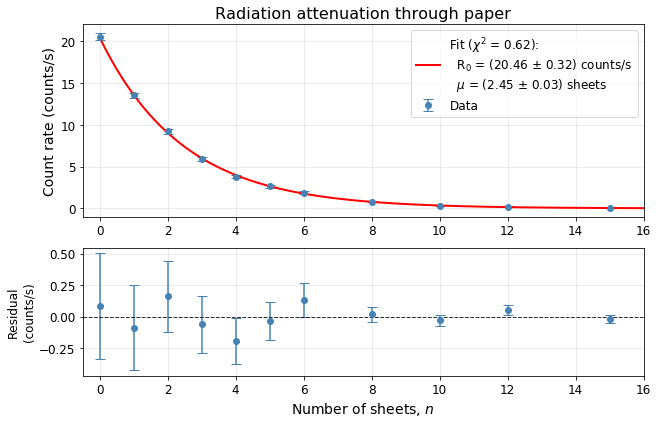

In [6]:
fig, ax = plt.subplots(2, 1, figsize=(9, 6),
                       gridspec_kw={'height_ratios': [3, 2]})

ax[0].errorbar(n_sheets, R_sub, yerr=dR_total,
               fmt='o', color='steelblue', capsize=5, label='Data')
n_fine = np.linspace(0, 16, 200)
ax[0].plot(n_fine, atten_model(n_fine, R0_full, mu_full), 'r-', lw=2,
           label=f'Fit ($\\chi^2$ = {chi2_red:.2f}):\n'
                 f'  R$_0$ = ({R0_full:.2f} $\\pm$ {dR0_full:.2f}) counts/s\n'
                 f'  $\\mu$ = ({mu_full:.2f} $\\pm$ {dmu_full:.2f}) sheets')
ax[0].set_ylabel('Count rate (counts/s)', fontsize=14)
ax[0].set_title('Radiation attenuation through paper', fontsize=16)
ax[0].legend(fontsize=12)
ax[0].tick_params(labelsize=12)
ax[0].set_xlim(-0.5, 16)
ax[0].set_ylim(bottom=-1)
ax[0].grid(True, alpha=0.3)

ax[1].errorbar(n_sheets, residuals, yerr=dR_total,
               fmt='o', color='steelblue', capsize=5)
ax[1].axhline(0, color='k', ls='--', lw=1, alpha=0.8)
ax[1].set_xlabel('Number of sheets, $n$', fontsize=14)
ax[1].set_ylabel('Residual\n(counts/s)', fontsize=12)
ax[1].tick_params(labelsize=12)
ax[1].set_xlim(-0.5, 16)
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.7 Step 2: uncertainty budget

For each source, we double its contribution to $\delta R_i$ and refit:

* **Counting statistics:** replace $\sqrt{N_i}/t_i$ with $2\sqrt{N_i}/t_i$, refit.
* **Timing:** replace $\delta t$ with $2\delta t$, refit.
* **Background:** replace $\delta R_{\text{bg}}$ with $2\,\delta R_{\text{bg}}$, refit.

Then extract each source's impact using

$$\text{impact}_j = \sqrt{\frac{\delta\mu_{\text{doubled},j}^2 - \delta\mu_{\text{full}}^2}{3}}.$$

In [7]:
# Double counting statistics
dR_2count = np.sqrt((2 * dR_count)**2 + dR_time**2 + dR_bg**2)
_, mu_2c, pcov_2c = fit_atten(n_sheets, R_sub, dR_2count)
dmu_2c = np.sqrt(pcov_2c[1, 1])

# Double timing
dR_2time = np.sqrt(dR_count**2 + (2 * dR_time)**2 + dR_bg**2)
_, mu_2t, pcov_2t = fit_atten(n_sheets, R_sub, dR_2time)
dmu_2t = np.sqrt(pcov_2t[1, 1])

# Double background
dR_2bg = np.sqrt(dR_count**2 + dR_time**2 + (2 * dR_bg)**2)
_, mu_2b, pcov_2b = fit_atten(n_sheets, R_sub, dR_2bg)
dmu_2b = np.sqrt(pcov_2b[1, 1])

# Impacts on μ
impact_count_mu = np.sqrt((dmu_2c**2 - dmu_full**2) / 3)
impact_time_mu = np.sqrt((dmu_2t**2 - dmu_full**2) / 3)
impact_bg_mu = np.sqrt((dmu_2b**2 - dmu_full**2) / 3)

print('μ budget')
print(f' • counting statistics: {impact_count_mu:.4f} sheets')
print(f' • timing:              {impact_time_mu:.4f} sheets')
print(f' • background:          {impact_bg_mu:.4f} sheets')

# Impacts on R₀
dR0_2c = np.sqrt(pcov_2c[0, 0])
dR0_2t = np.sqrt(pcov_2t[0, 0])
dR0_2b = np.sqrt(pcov_2b[0, 0])

impact_count_R0 = np.sqrt((dR0_2c**2 - dR0_full**2) / 3)
impact_time_R0 = np.sqrt((dR0_2t**2 - dR0_full**2) / 3)
impact_bg_R0 = np.sqrt((dR0_2b**2 - dR0_full**2) / 3)

print()
print('R₀ budget')
print(f' • counting statistics: {impact_count_R0:.4f} counts/s')
print(f' • timing:              {impact_time_R0:.4f} counts/s')
print(f' • background:          {impact_bg_R0:.4f} counts/s')

μ budget
 • counting statistics: 0.0329 sheets
 • timing:              0.0016 sheets
 • background:          0.0072 sheets

R₀ budget
 • counting statistics: 0.3180 counts/s
 • timing:              0.0237 counts/s
 • background:          0.0319 counts/s


### 3.8 Impact plots

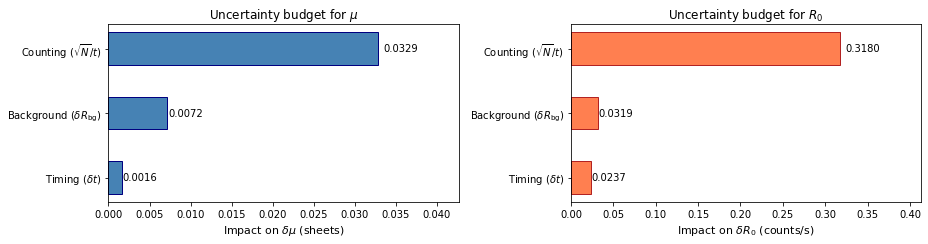

In [8]:
sources = [r'Counting ($\sqrt{N}/t$)',
           r'Timing ($\delta t$)',
           r'Background ($\delta R_{\rm bg}$)']

impacts_mu = [impact_count_mu, impact_time_mu, impact_bg_mu]
impacts_R0 = [impact_count_R0, impact_time_R0, impact_bg_R0]
order_mu = np.argsort(impacts_mu)[::-1]
order_R0 = np.argsort(impacts_R0)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))

ax = axes[0]
bars = ax.barh([sources[i] for i in order_mu],
               [impacts_mu[i] for i in order_mu],
               color='steelblue', edgecolor='navy', height=0.5)
ax.set_xlim(0, max(impacts_mu) * 1.3)
for bar, val in zip(bars, [impacts_mu[i] for i in order_mu]):
    ax.text(bar.get_width() * 1.02, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=10)
ax.set_xlabel(r'Impact on $\delta\mu$ (sheets)', fontsize=11)
ax.set_title(r'Uncertainty budget for $\mu$', fontsize=12)
ax.invert_yaxis()

ax = axes[1]
bars = ax.barh([sources[i] for i in order_R0],
               [impacts_R0[i] for i in order_R0],
               color='coral', edgecolor='firebrick', height=0.5)
ax.set_xlim(0, max(impacts_R0) * 1.3)
for bar, val in zip(bars, [impacts_R0[i] for i in order_R0]):
    ax.text(bar.get_width() * 1.02, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=10)
ax.set_xlabel(r'Impact on $\delta R_0$ (counts/s)', fontsize=11)
ax.set_title(r'Uncertainty budget for $R_0$', fontsize=12)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

### 3.9 Consistency checks

The impacts should add in quadrature and roughly match the full fit uncertainties:

$$\sqrt{\text{impact}_{\text{count}}^2 + \text{impact}_{\text{time}}^2 + \text{impact}_{\text{bg}}^2} \approx \delta\mu_{\text{full}}$$

A ratio near 1 means the identified sources account for the full uncertainty.

In [9]:
quad_mu = np.sqrt(impact_count_mu**2 + impact_time_mu**2 + impact_bg_mu**2)
quad_R0 = np.sqrt(impact_count_R0**2 + impact_time_R0**2 + impact_bg_R0**2)

print('μ budget')
print(f' • quadrature sum = {quad_mu:.4f} sheets')
print(f' • δμ (full fit)  = {dmu_full:.4f} sheets')
print(f' • ratio          = {quad_mu / dmu_full:.3f}')
print()
print('R₀ budget')
print(f' • quadrature sum = {quad_R0:.4f} counts/s')
print(f' • δR₀ (full fit) = {dR0_full:.4f} counts/s')
print(f' • ratio          = {quad_R0 / dR0_full:.3f}')

μ budget
 • quadrature sum = 0.0337 sheets
 • δμ (full fit)  = 0.0339 sheets
 • ratio          = 0.994

R₀ budget
 • quadrature sum = 0.3204 counts/s
 • δR₀ (full fit) = 0.3209 counts/s
 • ratio          = 0.999


**Discussion:** Both ratios are close to 1, confirming we have a complete set of independent uncertainty sources. Counting statistics dominates the budget for both parameters, with timing and background making smaller contributions. To improve the measurement of $\mu$, the priority is to count longer (especially at high $n$ where rates are low) to reduce the relative uncertainty associated with the (Poisson) counting uncertainty, $\delta N$.

## 4. Interpreting your uncertainty budget

The longest bar in the impact plot identifies the first place to focus if you want to reduce the overall uncertainty of your final result. Short bars represent smaller contributions, meaning that improving those will not help in a meaningful way until you have first improved the dominant source. 

The quadrature sum of all impacts should roughly match the full fit uncertainty. A large discrepancy might mean the sources are not truly independent, or that you have missed one.

## Acknowledgements

This document was developed with support from Claude, primarily related to syntax and formatting